# Which AI Concepts Are Most Central to Wikipedia's Coverage of Artificial Intelligence?

## 1. Research question and stakeholder

**Question:** Which AI concepts are most central to Wikipedia's coverage of artificial intelligence, and how do they group into topics?

**Stakeholder:** a tech content creator and educator planning an educational series on AI.

**Decision:** which concepts to cover early in the series and how to organize later content into themed segments.

**Network definition**

- **Node:** one English Wikipedia article about an AI or machine-learning concept.
- **Edge:** a directed hyperlink from one article's **body text** to another article in the set.

**Importance:** I use **PageRank** (`alpha=0.85`) as the primary measure and **in-degree** as the secondary one. A concept is considered central when it is frequently referenced by other AI articles, especially articles that are themselves central. These measures describe Wikipedia's hyperlink structure rather than verified learning prerequisites.

## 2. Collect the data

I collected articles through the MediaWiki API with `requests` and parsed article-body hyperlinks with `BeautifulSoup`; API responses were cached so the analysis can be reproduced.

In [1]:
import gzip
import hashlib
import json
import re
import time
import urllib.parse
from datetime import date
from pathlib import Path

import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
import pandas as pd
import requests
from bs4 import BeautifulSoup
from matplotlib.patches import Patch

REFRESH_DATA = False  # True = call the Wikipedia API; False = replay the cached responses
SEED = 414
SUBCATEGORY_DEPTH = 0  # 0 = direct category members only, 1 = also immediate subcategories
MIN_ARTICLE_BYTES = 15_000  # scope rule: keep substantively developed articles

SEED_CATEGORIES = [
    "Machine learning",
    "Deep learning",
    "Artificial neural networks",
    "Natural language processing",
    "Reinforcement learning",
    "Computer vision",
    "Large language models",
    "AI safety",  # selected after checking AI-ethics / AI-safety category alternatives
]

DATA_DIR = Path("data")
RAW_DIR = DATA_DIR / "raw"
FIG_DIR = Path("figures")
for _d in (RAW_DIR, FIG_DIR):
    _d.mkdir(parents=True, exist_ok=True)

API_URL = "https://en.wikipedia.org/w/api.php"
USER_AGENT = "INST414-wiki-network/1.0 (https://github.com/Heinlh; student project)"
REQUEST_PAUSE = 0.25  # seconds between requests, to stay polite to the API

plt.rcParams.update({"font.size": 11, "axes.spines.top": False,
                     "axes.spines.right": False, "figure.dpi": 110})

### Seed categories

I verified each candidate category through the API. `Artificial intelligence ethics` does not exist; among the alternatives I tested, `AI safety` had more direct article members than `Ethics of artificial intelligence`, so I used it as the eighth seed category.

In [2]:
SESSION = requests.Session()
SESSION.headers.update({"User-Agent": USER_AGENT})


def _cache_path(key):
    """Cache file for one request key, stored as gzipped JSON under data/raw/."""
    safe = re.sub(r"[^A-Za-z0-9._-]+", "_", key)[:100]
    digest = hashlib.md5(key.encode("utf-8")).hexdigest()[:8]
    return RAW_DIR / f"{safe}.{digest}.json.gz"


def api_pages(params, key, refresh=None):
    """Run one API query, follow every `continue` token, and cache the raw responses.

    Returns the list of raw JSON responses. With REFRESH_DATA False the cached
    responses are replayed and nothing touches the network.
    """
    refresh = REFRESH_DATA if refresh is None else refresh
    path = _cache_path(key)
    if path.exists() and not refresh:
        with gzip.open(path, "rt", encoding="utf-8") as fh:
            return json.load(fh)["responses"]
    if not refresh:
        raise FileNotFoundError(f"No cached response for {key!r}; set REFRESH_DATA = True.")

    responses, cont = [], {}
    while True:
        payload = _request({**params, "format": "json", "formatversion": 2,
                            "maxlag": 5, **cont})
        responses.append(payload)
        if "continue" not in payload:
            break
        cont = payload["continue"]
    with gzip.open(path, "wt", encoding="utf-8") as fh:
        json.dump({"collected_on": date.today().isoformat(), "responses": responses}, fh)
    return responses


def _request(query, attempts=5):
    """One GET, retrying with exponential backoff on network, maxlag, and API errors."""
    for attempt in range(attempts):
        time.sleep(REQUEST_PAUSE)
        try:
            response = SESSION.get(API_URL, params=query, timeout=60)
            response.raise_for_status()
            payload = response.json()
        except (requests.RequestException, ValueError) as exc:
            if attempt == attempts - 1:
                raise
            time.sleep(2 ** attempt)
            continue
        if "error" in payload:
            if attempt == attempts - 1:
                raise RuntimeError(payload["error"])
            time.sleep(2 ** attempt + 3)
            continue
        return payload
    raise RuntimeError("unreachable")


def collection_date(key):
    """Date the cached response for `key` was collected."""
    with gzip.open(_cache_path(key), "rt", encoding="utf-8") as fh:
        return json.load(fh)["collected_on"]


def batched(items, size=50):
    """Yield lists of at most `size` titles (the API limit for multi-title queries)."""
    items = list(items)
    for i in range(0, len(items), size):
        yield items[i:i + size]


def _batch_key(batch):
    """Short, stable cache key for a batch of titles."""
    return hashlib.md5("|".join(sorted(batch)).encode("utf-8")).hexdigest()[:16]


def category_exists(category):
    """True if Category:<category> exists on English Wikipedia."""
    page = api_pages({"action": "query", "titles": f"Category:{category}"},
                     f"catcheck_{category}")[0]["query"]["pages"][0]
    return not page.get("missing", False)


def category_members(category, namespace):
    """Titles in Category:<category> for one namespace (0 = articles, 14 = subcategories)."""
    params = {"action": "query", "list": "categorymembers",
              "cmtitle": f"Category:{category}", "cmnamespace": namespace,
              "cmtype": "page" if namespace == 0 else "subcat", "cmlimit": "max"}
    return [member["title"]
            for page in api_pages(params, f"catmembers_{category}_ns{namespace}")
            for member in page["query"]["categorymembers"]]


def collect_candidates(seed_categories, depth):
    """Map each candidate article title to the seed categories it was found in.

    Depth 0 takes direct members only; depth 1 also takes the members of each
    seed category's immediate subcategories. The first seed that contributed a
    title becomes its primary seed. Also returns the raw membership row count,
    which counts an article once per category it appears in.
    """
    seeds, raw_rows = {}, 0
    for seed in seed_categories:
        categories = [seed]
        if depth >= 1:
            categories += [c.removeprefix("Category:") for c in category_members(seed, 14)]
        for category in categories:
            for title in category_members(category, 0):
                raw_rows += 1
                found_in = seeds.setdefault(title, [])
                if seed not in found_in:
                    found_in.append(seed)
    return seeds, raw_rows

In [3]:
CANDIDATE_CATEGORIES = [
    "Machine learning", "Deep learning", "Artificial neural networks",
    "Natural language processing", "Reinforcement learning", "Computer vision",
    "Large language models",
    # The AI-ethics / AI-safety slot: I checked three names and kept the one
    # that exists and has the most article members.
    "Artificial intelligence ethics", "Ethics of artificial intelligence", "AI safety",
]

category_check = pd.DataFrame({
    "Category": CANDIDATE_CATEGORIES,
    "Exists": [category_exists(c) for c in CANDIDATE_CATEGORIES],
})
category_check["Article members"] = [
    len(category_members(c, 0)) if exists else 0
    for c, exists in zip(category_check.Category, category_check.Exists)
]
category_check["Used as a seed"] = category_check.Category.isin(SEED_CATEGORIES)
category_check

,Category,Exists,Article members,Used as a seed
0,Machine learning,True,291,True
1,Deep learning,True,65,True
2,Artificial neural networks,True,158,True
3,Natural language processing,True,233,True
4,Reinforcement learning,True,19,True
5,Computer vision,True,133,True
6,Large language models,True,118,True
7,Artificial intelligence ethics,False,0,False
8,Ethics of artificial intelligence,True,12,False
9,AI safety,True,33,True


In [4]:
def page_flags(titles):
    """Map title -> True when the page is a disambiguation page (prop=pageprops)."""
    flags = {}
    for batch in batched(titles):
        params = {"action": "query", "prop": "pageprops", "ppprop": "disambiguation",
                  "titles": "|".join(batch)}
        for page in api_pages(params, f"pageprops_{_batch_key(batch)}"):
            for item in page["query"]["pages"]:
                flags[item["title"]] = "disambiguation" in item.get("pageprops", {})
    return flags


def page_categories(titles):
    """Map title -> its non-hidden categories (prop=categories, hidden ones excluded)."""
    categories = {}
    for batch in batched(titles):
        params = {"action": "query", "prop": "categories", "clshow": "!hidden",
                  "cllimit": "max", "titles": "|".join(batch)}
        for page in api_pages(params, f"categories_{_batch_key(batch)}"):
            for item in page["query"]["pages"]:
                categories.setdefault(item["title"], []).extend(
                    c["title"].removeprefix("Category:") for c in item.get("categories", []))
    return categories


def page_lengths(titles):
    """Map title -> article size in bytes (prop=info)."""
    lengths = {}
    for batch in batched(titles):
        params = {"action": "query", "prop": "info", "titles": "|".join(batch)}
        for page in api_pages(params, f"info_{_batch_key(batch)}"):
            for item in page["query"]["pages"]:
                lengths[item["title"]] = item.get("length", 0)
    return lengths


def canonical_titles(titles):
    """Map each title to its canonical form, following normalisation and redirects."""
    mapping = {}
    for batch in batched(titles):
        params = {"action": "query", "redirects": 1, "titles": "|".join(batch)}
        payload = api_pages(params, f"redirects_{_batch_key(batch)}")[0]["query"]
        steps = {item["from"]: item["to"] for kind in ("normalized", "redirects")
                 for item in payload.get(kind, [])}
        for title in batch:
            seen, current = set(), title
            while current in steps and current not in seen:
                seen.add(current)
                current = steps[current]
            mapping[title] = current
    return mapping


def redirect_aliases(titles):
    """Map every article-space redirect pointing at a node to that node's title."""
    aliases = {}
    for batch in batched(titles):
        params = {"action": "query", "prop": "redirects", "rdnamespace": 0,
                  "rdlimit": "max", "titles": "|".join(batch)}
        for page in api_pages(params, f"aliases_{_batch_key(batch)}"):
            for item in page["query"]["pages"]:
                for redirect in item.get("redirects", []):
                    aliases[redirect["title"]] = item["title"]
    return aliases


DROP_SELECTORS = [".navbox", ".vertical-navbox", ".sidebar", ".infobox", ".hatnote",
                  ".reflist", ".refbegin", ".mw-references-wrap", ".metadata",
                  ".catlinks", ".mw-editsection", "table.ambox"]
DROP_SECTIONS = {"References", "External_links", "Further_reading"}
LINK_CONTAINERS = ["p", "ul", "ol", "dl", "blockquote"]


def article_html(title):
    """Rendered HTML of one article (action=parse), cached per article."""
    payload = api_pages({"action": "parse", "page": title, "prop": "text",
                         "redirects": 1}, f"parse_{title}")[0]
    return payload["parse"]["title"], payload["parse"]["text"]


def clean_body(html):
    """Strip navboxes, infoboxes, references, and the excluded sections.

    Returns (content root, {element id -> section heading}) so each surviving
    link can be traced back to the section it came from.
    """
    root = BeautifulSoup(html, "lxml").select_one("div.mw-parser-output")
    for selector in DROP_SELECTORS:
        for tag in root.select(selector):
            tag.decompose()

    sections, current = {}, "__lead__"
    for child in list(root.find_all(recursive=False)):
        heading = child if child.name == "h2" else child.find("h2", recursive=False)
        if heading is not None:
            headline = heading.find(class_="mw-headline")
            current = (heading.get("id") or (headline.get("id") if headline else None)
                       or heading.get_text(strip=True).replace(" ", "_"))
        if current in DROP_SECTIONS:
            child.decompose()
            continue
        sections[id(child)] = current
    return root, sections


def body_links(title, html):
    """Every body-text anchor in one article, as (source, raw_target, from_see_also).

    `raw_target` is None for anchors that are not plain article links, so the
    cleaning funnel can count how many were dropped.
    """
    root, sections = clean_body(html)
    rows = []
    for child in root.find_all(recursive=False):
        section = sections.get(id(child))
        if section is None:
            continue
        containers = ([child] if child.name in LINK_CONTAINERS else []) \
            + child.find_all(LINK_CONTAINERS)
        for container in containers:
            for anchor in container.find_all("a", href=True):
                rows.append({"source": title, "raw_target": link_target(anchor),
                             "from_see_also": section == "See_also"})
    return rows


def link_target(anchor):
    """Article title an <a> points at, or None if it is not a plain article link."""
    href = anchor["href"]
    if not href.startswith("/wiki/"):
        return None
    if "new" in (anchor.get("class") or []):  # red link: the article does not exist
        return None
    target = urllib.parse.unquote(href[len("/wiki/"):].split("#")[0]).replace("_", " ")
    if not target or ":" in target:  # namespace prefix (File:, Help:, Category: ...)
        return None
    return target


def all_links(titles):
    """prop=links edges for the node set: body text plus navboxes and sidebars."""
    links = []
    for batch in batched(titles):
        params = {"action": "query", "prop": "links", "plnamespace": 0,
                  "pllimit": "max", "titles": "|".join(batch)}
        for page in api_pages(params, f"alllinks_{_batch_key(batch)}"):
            for item in page["query"]["pages"]:
                links += [(item["title"], link["title"]) for link in item.get("links", [])]
    return links


LIST_PREFIXES = ("List of", "Outline of", "Glossary of", "Timeline of", "Index of")


def is_person(categories):
    """True when a page's categories mark it as a biography."""
    return any(c == "Living people" or c.endswith(" births") or c.endswith(" deaths")
               for c in categories)


def is_organization(categories):
    """True when a page's categories mark it as a company or organization."""
    return any("companies" in c.lower() or "organizations" in c.lower() for c in categories)

### Fields I use

| Field | Where it comes from | Why it matters |
|---|---|---|
| `title` | `list=categorymembers`, canonicalised with `redirects=1` | Identifies each node |
| `seed_categories` | Which seed categories an article was found in | Labels not used by Louvain, used to compare the clusters with Wikipedia's category structure |
| `primary_seed` | The first seed category that contributed the article | One label per node for the cluster crosstab |
| `article_bytes` | `prop=info` | Scope rule: keeps substantively developed articles |
| `is_disambiguation` | `prop=pageprops&ppprop=disambiguation` | Disambiguation pages are navigation, not concepts |
| Non-hidden categories | `prop=categories&clshow=!hidden` | Used to drop people and organizations |
| `source`, `target` | `<a href="/wiki/...">` in the cleaned article body | The edges themselves |
| `from_see_also` | The section the link was found in | Distinguishes prose links from "See also" pointers |

### Building the node set and the edge set

`build_nodes` walks the filter funnel in a fixed order and returns the counts at every step. `build_edges` fetches each article's rendered HTML, strips the navigation furniture, and keeps only links whose target is another article in the node set.

In [5]:
def build_nodes(seed_categories, depth, min_bytes):
    """Collect candidate articles and filter them down to concept articles.

    Returns (nodes DataFrame, funnel counts, canonical-title map).
    """
    candidates, raw_rows = collect_candidates(seed_categories, depth)
    funnel = {"Raw category members (one row per article per category)": raw_rows,
              "After namespace filter and de-duplication (unique articles)": len(candidates)}

    titles = sorted(candidates)
    disambiguation = page_flags(titles)
    titles = [t for t in titles if not disambiguation.get(t, False)]
    funnel["After removing disambiguation pages"] = len(titles)

    titles = [t for t in titles if not t.startswith(LIST_PREFIXES)]
    funnel["After removing lists and outlines"] = len(titles)

    categories = page_categories(titles)
    titles = [t for t in titles if not is_person(categories.get(t, []))]
    funnel["After removing people"] = len(titles)

    titles = [t for t in titles if not is_organization(categories.get(t, []))]
    funnel["After removing organizations"] = len(titles)

    canonical = canonical_titles(titles)
    merged = {}
    for title in titles:
        merged.setdefault(canonical[title], []).extend(candidates[title])
    funnel["After redirect de-duplication"] = len(merged)

    lengths = page_lengths(sorted(merged))
    merged = {t: s for t, s in merged.items() if lengths.get(t, 0) >= min_bytes}
    funnel[f"After removing articles under {min_bytes:,} bytes"] = len(merged)

    nodes = pd.DataFrame({
        "title": list(merged),
        "seed_categories": [list(dict.fromkeys(s)) for s in merged.values()],
    }).sort_values("title", ignore_index=True)
    nodes["primary_seed"] = nodes.seed_categories.str[0]
    nodes["article_bytes"] = nodes.title.map(lengths)
    nodes["is_disambiguation"] = False  # every disambiguation page was filtered out above
    funnel["Final nodes"] = len(nodes)
    return nodes, funnel, canonical


def build_edges(node_titles, aliases):
    """Fetch each article's HTML and keep the body links that point inside the node set."""
    node_set = set(node_titles)
    raw = []
    for title in node_titles:
        resolved, html = article_html(title)
        raw += body_links(title, html)
    edges = pd.DataFrame(raw, columns=["source", "raw_target", "from_see_also"])
    funnel = {"Raw body-text links": len(edges)}

    edges = edges.dropna(subset=["raw_target"])
    funnel["Valid article links (no red links, no namespaces)"] = len(edges)
    edges["target"] = edges.raw_target.map(lambda t: aliases.get(t, t))

    edges = edges[edges.target.isin(node_set) & edges.source.isin(node_set)]
    funnel["Links whose target is in the node set"] = len(edges)

    edges = edges[edges.source != edges.target]
    edges = (edges.sort_values("from_see_also", ascending=False)
             .drop_duplicates(["source", "target"])
             .sort_values(["source", "target"], ignore_index=True))
    funnel["After removing self-links and duplicates"] = len(edges)
    return edges[["source", "target", "from_see_also"]], funnel

In [6]:
nodes, node_funnel, canonical = build_nodes(SEED_CATEGORIES, SUBCATEGORY_DEPTH, MIN_ARTICLE_BYTES)
aliases = redirect_aliases(nodes.title.tolist())

print(f"Collected on: {collection_date('catmembers_Machine learning_ns0')}")
print(f"Nodes: {len(nodes):,} | redirect aliases resolved into the node set: {len(aliases):,}")
nodes.head()

Collected on: 2026-09-23
Nodes: 310 | redirect aliases resolved into the node set: 2,015


,title,seed_categories,primary_seed,article_bytes,is_disambiguation
0,3D Morphable Model,[Computer vision],Computer vision,34841,False
1,3D body scanning,[Computer vision],Computer vision,15249,False
2,3D reconstruction,[Computer vision],Computer vision,35190,False
3,3D reconstruction from multiple images,[Computer vision],Computer vision,23655,False
4,3D scanning,[Computer vision],Computer vision,86320,False


## 3. Clean and validate the input data

### Filter funnel

The seed categories return a lot that is not an AI *concept*: disambiguation pages, list and outline articles, biographies of researchers, and company articles. I remove each of those in turn and count what goes.

The last rule is a scope decision rather than a correctness rule. Wikipedia's AI categories have a long tail of very short articles about single products, individual laws, and narrow applications. I keep only articles of at least 15,000 bytes, which holds the study to substantively developed topics and brings the node count into the range this assignment asks for. Section 8 lists the bias this introduces.

In [7]:
pd.DataFrame({"Articles": node_funnel}).assign(
    Removed=lambda d: -d.Articles.diff().fillna(0).astype(int))

,Articles,Removed
Raw category members (one row per article per category),1050,0
After namespace filter and de-duplication (unique articles),948,102
After removing disambiguation pages,948,0
After removing lists and outlines,938,10
After removing people,932,6
After removing organizations,879,53
After redirect de-duplication,869,10
"After removing articles under 15,000 bytes",310,559
Final nodes,310,0


In [8]:
edges, edge_funnel = build_edges(nodes.title.tolist(), aliases)
pd.DataFrame({"Links": edge_funnel}).assign(
    Removed=lambda d: -d.Links.diff().fillna(0).astype(int))

,Links,Removed
Raw body-text links,43699,0
"Valid article links (no red links, no namespaces)",23563,20136
Links whose target is in the node set,3392,20171
After removing self-links and duplicates,2369,1023


In [9]:
# Stop the notebook if the cleaned data breaks any rule.
assert nodes.title.is_unique
assert not edges.duplicated(["source", "target"]).any()
assert not (edges.source == edges.target).any()
assert set(edges.source) <= set(nodes.title) and set(edges.target) <= set(nodes.title)

pd.Series({
    "Nodes": len(nodes),
    "Edges": len(edges),
    "Edges from a 'See also' section": int(edges.from_see_also.sum()),
    "Edges from ordinary body prose": int((~edges.from_see_also).sum()),
}, name="Count").to_frame()

,Count
Nodes,310
Edges,2369
Edges from a 'See also' section,273
Edges from ordinary body prose,2096


### Why I excluded navigation boxes

Wikipedia's `prop=links` returns every link on a page, including the navigation boxes at the foot of the article. A navigation box lists dozens of related articles and is transcluded identically onto all of them, so it links every member to every other member and manufactures a clique that no editor wrote into any sentence. The comparison below is the reason I parsed the HTML body instead.

In [10]:
node_set = set(nodes.title)
nav_edges = {(s, aliases.get(t, t)) for s, t in all_links(nodes.title.tolist())}
nav_edges = {(s, t) for s, t in nav_edges if t in node_set and s != t}
body_edges = set(zip(edges.source, edges.target))

pd.Series({
    "In-set edges from body text only (what I use)": len(body_edges),
    "In-set edges from prop=links (body text + navboxes + sidebars)": len(nav_edges),
    "Extra edges navboxes and sidebars would have added": len(nav_edges - body_edges),
    "Increase": f"{len(nav_edges - body_edges) / len(body_edges):.0%}",
    "Body-text edges prop=links does not report": len(body_edges - nav_edges),
}, name="Value").to_frame()

,Value
In-set edges from body text only (what I use),2369
In-set edges from prop=links (body text + navboxes + sidebars),8799
Extra edges navboxes and sidebars would have added,6430
Increase,271%
Body-text edges prop=links does not report,0


## 4. Build the network

I build a **directed** graph, because a hyperlink points one way: an article about `Overfitting` mentioning `Cross-validation (statistics)` does not mean the reverse link exists. Every article in the node set becomes a node even if nothing links to it.

In [11]:
G = nx.DiGraph()
G.add_nodes_from(nodes.title)
G.add_edges_from(zip(edges.source, edges.target))
UG = G.to_undirected()

assert G.number_of_edges() == len(edges)

largest_component = max(nx.weakly_connected_components(G), key=len)
reciprocal = sum(1 for u, v in G.edges() if G.has_edge(v, u))

pd.Series({
    "Nodes": G.number_of_nodes(),
    "Edges": G.number_of_edges(),
    "Density": f"{nx.density(G):.4f}",
    "Nodes with no in-set links": nx.number_of_isolates(G),
    "Share of nodes in the largest weakly connected component":
        f"{len(largest_component) / G.number_of_nodes():.1%}",
    "Mean total degree (in + out)":
        f"{sum(d for _, d in G.degree()) / G.number_of_nodes():.1f}",
    "Reciprocated links (both directions present)":
        f"{reciprocal / G.number_of_edges():.1%}",
}, name="Value").to_frame()

,Value
Nodes,310
Edges,2369
Density,0.0247
Nodes with no in-set links,3
Share of nodes in the largest weakly connected component,99.0%
Mean total degree (in + out),15.3
Reciprocated links (both directions present),35.0%


## 5. Measure importance

**Primary: PageRank.** PageRank spreads score along incoming links, so an article gains more from being linked by a well-linked article than by an obscure one. Here, a higher PageRank means the concept is a more central reference point in Wikipedia's AI hyperlink network.

**Secondary: in-degree.** A plain count of how many articles in the set link to a concept. It is easier to explain and acts as a check on PageRank.

I also compute **betweenness centrality** on the undirected graph, and the Louvain communities described in section 6, so that every result can be shown in one table.

In [12]:
pagerank = nx.pagerank(G, alpha=0.85)
betweenness = nx.betweenness_centrality(UG, seed=SEED)
communities = nx.community.louvain_communities(UG, seed=SEED, resolution=1.0)
modularity = nx.community.modularity(UG, communities)

assert sum(d for _, d in G.in_degree()) == G.number_of_edges()
assert np.isclose(sum(pagerank.values()), 1.0)

# Number the communities from largest to smallest; anything under 10 nodes is "Other".
ordered = sorted(communities, key=len, reverse=True)
community_of = {n: (f"C{i + 1}" if len(c) >= 10 else "Other")
                for i, c in enumerate(ordered) for n in c}

results = nodes.assign(
    pagerank=nodes.title.map(pagerank),
    in_degree=nodes.title.map(dict(G.in_degree())),
    out_degree=nodes.title.map(dict(G.out_degree())),
    betweenness=nodes.title.map(betweenness),
    community=nodes.title.map(community_of),
).sort_values("pagerank", ascending=False, ignore_index=True)
results.insert(0, "rank", results.index + 1)

(results.head(20)[["rank", "title", "pagerank", "in_degree", "out_degree",
                   "community", "primary_seed"]]
 .rename(columns={"rank": "Rank", "title": "Article", "pagerank": "PageRank",
                  "in_degree": "In-degree", "out_degree": "Out-degree",
                  "community": "Community", "primary_seed": "Primary seed category"})
 .style.hide(axis="index").format({"PageRank": "{:.4f}"})
 .set_caption("Top 20 articles by PageRank"))

Rank,Article,PageRank,In-degree,Out-degree,Community,Primary seed category
1,Machine learning,0.0532,138,51,C3,Machine learning
2,Neural network (machine learning),0.0372,96,48,C1,Artificial neural networks
3,Deep learning,0.0306,88,51,C1,Deep learning
4,Computer vision,0.0305,77,20,C4,Computer vision
5,Natural language processing,0.0268,74,30,C5,Natural language processing
6,Large language model,0.0175,67,47,C2,Deep learning
7,"Training, validation, and test data sets",0.0171,49,4,C2,Machine learning
8,Feature (machine learning),0.0161,29,8,C3,Machine learning
9,Overfitting,0.0147,34,5,C3,Machine learning
10,Convolutional neural network,0.0144,60,34,C1,Computer vision


In [13]:
# Do the two importance measures agree?
top_pagerank = set(results.head(20).title)
top_in_degree = set(results.nlargest(20, "in_degree").title)
overlap = len(top_pagerank & top_in_degree)
print(f"{overlap} of the top 20 by PageRank are also in the top 20 by in-degree.")
print("Only in the PageRank top 20:", sorted(top_pagerank - top_in_degree))
print("Only in the in-degree top 20:", sorted(top_in_degree - top_pagerank))

17 of the top 20 by PageRank are also in the top 20 by in-degree.
Only in the PageRank top 20: ['Cross-validation (statistics)', 'Pattern recognition', 'Representation learning']
Only in the in-degree top 20: ['Attention (machine learning)', 'Fine-tuning (deep learning)', 'Generative AI']


PageRank and in-degree produced similar top concepts, increasing confidence that the highest-ranked articles are central reference points.

### Bridge concepts

Betweenness centrality counts how often an article sits on the shortest path between other articles. High-betweenness concepts connect different topic groups, making them useful transition topics between segments of an educational series.

In [14]:
(results.nlargest(10, "betweenness")[["title", "betweenness", "pagerank", "community"]]
 .rename(columns={"title": "Article", "betweenness": "Betweenness",
                  "pagerank": "PageRank", "community": "Community"})
 .style.hide(axis="index").format({"Betweenness": "{:.4f}", "PageRank": "{:.4f}"})
 .set_caption("Bridge concepts: top 10 by betweenness centrality"))

Article,Betweenness,PageRank,Community
Machine learning,0.2962,0.0532,C3
Computer vision,0.1285,0.0305,C4
Neural network (machine learning),0.1114,0.0372,C1
Deep learning,0.1047,0.0306,C1
Natural language processing,0.0833,0.0268,C5
Large language model,0.0648,0.0175,C2
Convolutional neural network,0.0569,0.0144,C1
Generative AI,0.0256,0.0082,C2
"Training, validation, and test data sets",0.0232,0.0171,C2
ChatGPT,0.0213,0.0108,C2


## 6. Find topic clusters

**Method.** I used **Louvain** (`nx.community.louvain_communities`) on the undirected version of the graph with `seed=414` and `resolution=1.0`. Louvain maximises modularity, which measures how much denser the links inside groups are than you would expect by chance. I tested Girvan–Newman, the method from lecture, but it produced highly unbalanced communities on this graph, so I used Louvain for the final clustering.

In [15]:
COMMUNITY_LABELS = {  # keyed on the community's highest-PageRank article
    "Neural network (machine learning)": "Neural network foundations",
    "Large language model": "Large language models and generative AI",
    "Machine learning": "Core machine learning and evaluation",
    "Computer vision": "Computer vision and image processing",
    "Natural language processing": "Natural language processing",
    "Reinforcement learning": "Reinforcement learning",
}

# I label each community based on its highest-PageRank articles.
summary = []
for name, group in results.groupby("community"):
    top5 = group.nlargest(5, "pagerank").title.tolist()
    summary.append({
        "Community": name,
        "Size": len(group),
        "Label": COMMUNITY_LABELS.get(top5[0], "Mixed small communities"),
        "Top 5 articles by PageRank": ", ".join(top5),
    })
community_table = (pd.DataFrame(summary)
                   .sort_values("Size", ascending=False, ignore_index=True))

print(f"Louvain communities: {len(communities)} "
      f"({sum(len(c) >= 10 for c in communities)} with at least 10 nodes)")
print(f"Modularity: {modularity:.3f}")
community_table.style.hide(axis="index").set_caption(
    "Louvain communities (labels are my interpretation of the top articles, not algorithm output)")

Louvain communities: 9 (6 with at least 10 nodes)
Modularity: 0.382


Community,Size,Label,Top 5 articles by PageRank
C1,76,Neural network foundations,"Neural network (machine learning), Deep learning, Convolutional neural network, Backpropagation, Activation function"
C2,66,Large language models and generative AI,"Large language model, Training, validation, and test data sets, ChatGPT, Generative AI, Fine-tuning (deep learning)"
C3,59,Core machine learning and evaluation,"Machine learning, Feature (machine learning), Overfitting, Cross-validation (statistics), Time series"
C4,51,Computer vision and image processing,"Computer vision, Feature engineering, Pattern recognition, 3D scanning, Structured-light 3D scanner"
C5,45,Natural language processing,"Natural language processing, Representation learning, Information retrieval, Word embedding, Word2Vec"
C6,10,Reinforcement learning,"Reinforcement learning, Proximal policy optimization, Q-learning, Deep reinforcement learning, Policy gradient method"
Other,3,Mixed small communities,"Shape context, Developmental robotics, Wispr Flow"


In [16]:
# Girvan-Newman for comparison: its first split on the largest component.
start = time.time()
first_split = next(nx.community.girvan_newman(UG.subgraph(largest_component)))
print(f"Girvan-Newman first split: {time.time() - start:.1f}s, "
      f"group sizes {sorted((len(c) for c in first_split), reverse=True)}")
print(f"Louvain, for comparison: group sizes "
      f"{sorted((len(c) for c in communities), reverse=True)}")

Girvan-Newman first split: 0.7s, group sizes [304, 3]
Louvain, for comparison: group sizes [76, 66, 59, 51, 45, 10, 1, 1, 1]


### Cluster validation

The communities come only from the link structure; the seed categories come from Wikipedia's editors. If the two mostly agree, the clusters are picking up something real rather than an artefact of the algorithm. **Purity** below is the share of a community's articles whose primary seed category is that community's most common one.

In [17]:
crosstab = pd.crosstab(results.community, results.primary_seed)
display(crosstab.loc[:, crosstab.sum().sort_values(ascending=False).index])

purity = pd.DataFrame({
    "Size": crosstab.sum(axis=1),
    "Most common primary seed": crosstab.idxmax(axis=1),
    "Purity": crosstab.max(axis=1) / crosstab.sum(axis=1),
}).sort_values("Size", ascending=False)
purity.style.format({"Purity": "{:.0%}"}).set_caption(
    "How closely each community matches Wikipedia's own seed categories")

primary_seed,Machine learning,Natural language processing,Computer vision,Artificial neural networks,Deep learning,Large language models,AI safety,Reinforcement learning
community,,,,,,,,
C1,14,3,8,33,16,0,1,1
C2,20,6,0,2,6,25,6,1
C3,53,3,1,2,0,0,0,0
C4,14,1,33,1,2,0,0,0
C5,9,30,0,2,2,2,0,0
C6,3,0,0,0,2,0,0,5
Other,1,1,1,0,0,0,0,0


,Size,Most common primary seed,Purity
community,,,
C1,76,Artificial neural networks,43%
C2,66,Large language models,38%
C3,59,Machine learning,90%
C4,51,Computer vision,65%
C5,45,Natural language processing,67%
C6,10,Reinforcement learning,50%
Other,3,Computer vision,33%


Some communities match Wikipedia's own categories closely: C3, C4, and C5 track `Machine learning`, `Computer vision`, and `Natural language processing`. Others combine related categories: C1 merges neural networks with deep learning, and C2 merges large language models with AI safety. The seed categories are not ground truth, so a mixed community means the link structure groups these topics differently from the category tree, not that the clustering is wrong.

## 7. Visualize the results

### Figure 1: the clustered network

I draw the largest weakly connected component. Nodes are colored by community; positions are arranged for readability and should not be interpreted as meaningful distances. The nodes are unlabelled so the group structure stays legible; the named concepts are in the top-20 table in section 5 and in Figure 2 below.

In [18]:
PALETTE = ["#56B4E9", "#E69F00", "#009E73", "#CC79A7", "#D55E00", "#F0E442"]
labels_by_community = dict(zip(community_table.Community, community_table["Label"]))
big_communities = [c for c in community_table.Community if c != "Other"]
color_of = {c: PALETTE[i % len(PALETTE)] for i, c in enumerate(big_communities)}
color_of["Other"] = "#9AA0A6"

H = G.subgraph(largest_component)
members = {c: [n for n in H if community_of[n] == c] for c in color_of}
members = {c: group for c, group in members.items() if group}

# Order the communities around a circle by how the community-to-community graph
# lays out, so groups that link to each other a lot end up side by side.
meta = nx.Graph()
meta.add_nodes_from(members)
for u, v in H.edges():
    a, b = community_of[u], community_of[v]
    if a != b:
        meta.add_edge(a, b, weight=meta.get_edge_data(a, b, {"weight": 0})["weight"] + 1)
meta_pos = nx.spring_layout(meta, seed=SEED, weight="weight")
order = sorted(members, key=lambda c: np.arctan2(*meta_pos[c][::-1]))

RING = 3.6
centers = {c: RING * np.array([np.cos(a), np.sin(a)])
           for c, a in zip(order, np.linspace(0, 2 * np.pi, len(order), endpoint=False))}

pos = {}
for community, group in members.items():
    # Lay out the undirected subgraph: link direction would skew the spring forces.
    local = nx.spring_layout(UG.subgraph(group), seed=SEED, k=1.1, iterations=400)
    xy = np.array([local[n] for n in group])
    xy -= xy.mean(axis=0)
    radius = np.linalg.norm(xy, axis=1).max() or 1.0  # fit each community in its own disc
    xy *= RING * (0.24 + 0.52 * np.sqrt(len(group) / 76)) / radius
    pos.update(dict(zip(group, xy + centers[community])))

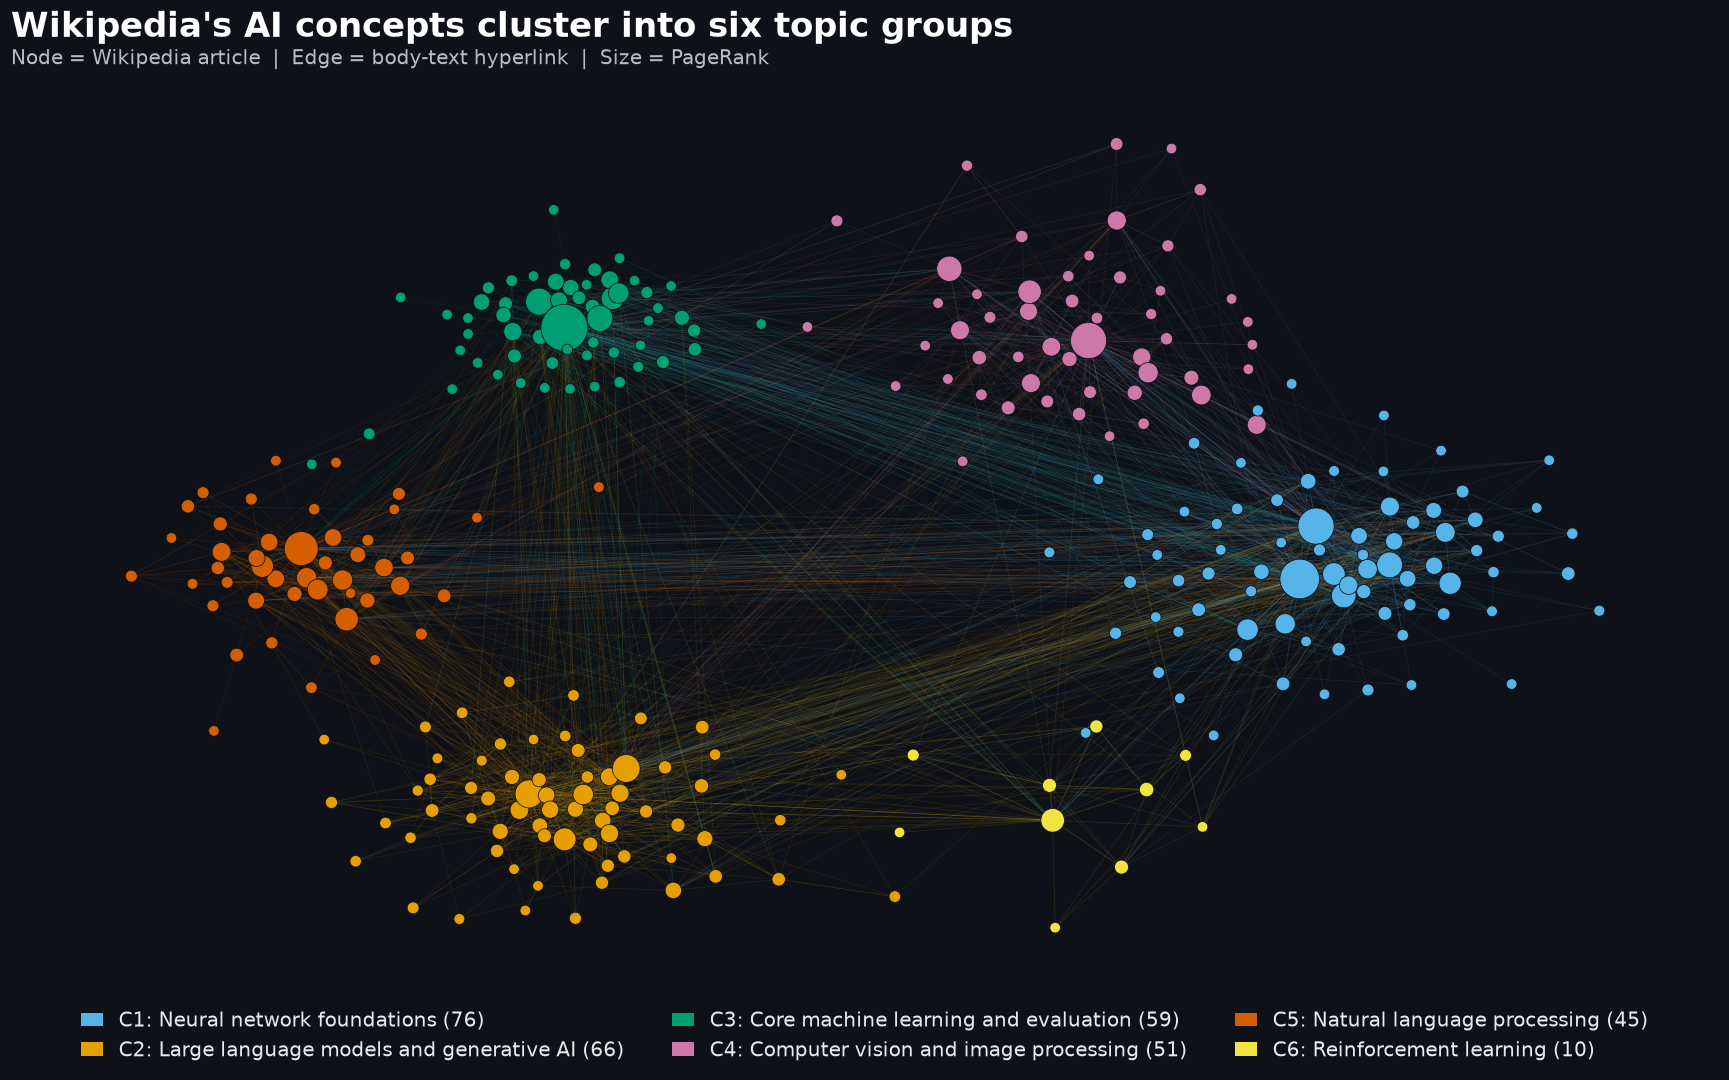

In [19]:
nodelist = list(H)
sizes = [40 + 17_000 * pagerank[n] for n in nodelist]

fig, ax = plt.subplots(figsize=(16, 10.5), facecolor="#0E1117")
ax.set_facecolor("#0E1117")
for community in members:  # edges take the colour of the article they start from
    batch = [(u, v) for u, v in H.edges() if community_of[u] == community]
    nx.draw_networkx_edges(H, pos, edgelist=batch, ax=ax, edge_color=color_of[community],
                           alpha=0.11, width=0.5, arrows=False)
nx.draw_networkx_nodes(H, pos, nodelist=nodelist, ax=ax, node_size=sizes,
                       node_color=[color_of[community_of[n]] for n in nodelist],
                       edgecolors="#0E1117", linewidths=0.5)

ax.set_title("Wikipedia's AI concepts cluster into six topic groups",
             color="white", fontsize=22, fontweight="bold", loc="left", pad=28)
ax.text(0, 1.017, "Node = Wikipedia article  |  Edge = body-text hyperlink  |  "
                  "Size = PageRank",
        transform=ax.transAxes, color="#B7BDC6", fontsize=13)
ax.legend(handles=[Patch(facecolor=color_of[c], edgecolor="none",
                         label=f"{c}: {labels_by_community[c]} "
                               f"({len(members[c])})")
                   for c in community_table.Community if c in members],
          loc="upper center", bbox_to_anchor=(0.5, -0.008), ncol=3, frameon=False,
          labelcolor="#E8EAED", fontsize=13, handlelength=1.1, columnspacing=2.4)
ax.margins(0.03)
ax.axis("off")
fig.subplots_adjust(left=0.015, right=0.985, top=0.90, bottom=0.115)
fig.savefig(FIG_DIR / "network_clusters.png", dpi=220, facecolor=fig.get_facecolor())
plt.show()

### Figure 2: the 20 highest-PageRank concepts

The same colours as Figure 1, so a bar's colour shows which topic group the concept belongs to.

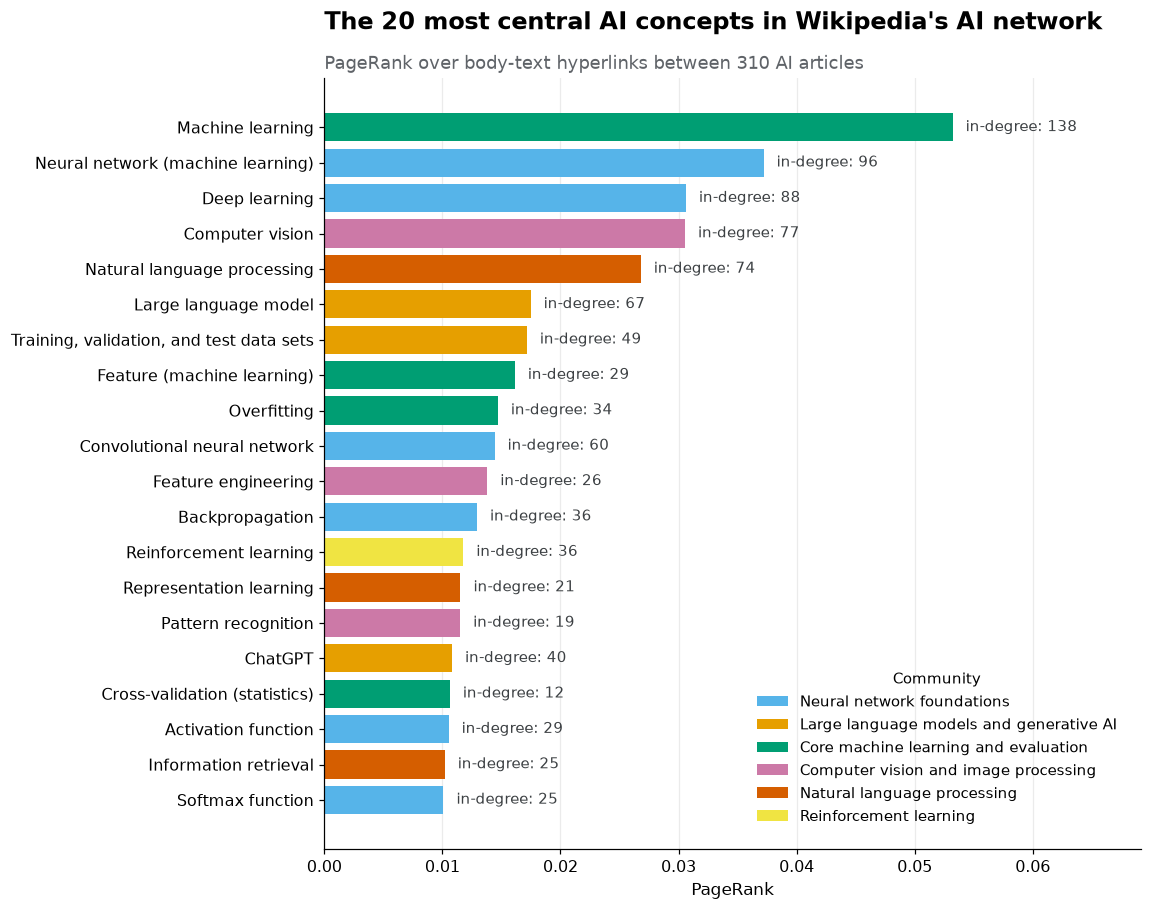

In [20]:
plot_df = results.head(20).iloc[::-1]

fig, ax = plt.subplots(figsize=(11, 8.6))
bars = ax.barh(plot_df.title, plot_df.pagerank,
               color=[color_of[c] for c in plot_df.community])
ax.bar_label(bars, labels=[f"  in-degree: {d}" for d in plot_df.in_degree],
             padding=2, fontsize=9.5, color="#3C4043")
ax.set_title("The 20 most central AI concepts in Wikipedia\'s AI network",
             loc="left", fontweight="bold", fontsize=16, pad=32)
ax.text(0, 1.012, f"PageRank over body-text hyperlinks between "
                  f"{G.number_of_nodes()} AI articles",
        transform=ax.transAxes, color="#5F6368", fontsize=11.5)
ax.set_xlabel("PageRank")
ax.set_xlim(0, plot_df.pagerank.max() * 1.30)
ax.grid(axis="x", alpha=0.25)
ax.set_axisbelow(True)
ax.tick_params(labelsize=10.5)
ax.legend(handles=[Patch(facecolor=color_of[c],
                         label=labels_by_community[c])
                   for c in big_communities if c in set(plot_df.community)],
          loc="lower right", frameon=False, fontsize=10, title="Community",
          title_fontsize=10, borderaxespad=1.2)
fig.subplots_adjust(left=0.30, right=0.975, top=0.90, bottom=0.085)
fig.savefig(FIG_DIR / "top20_pagerank.png", dpi=220)
plt.show()

## 8. Validate the output, answer the question, and discuss limitations

### Output checks

Structural assertions in sections 3 to 5 stop the notebook if the data breaks any rule: unique titles, no self-links or duplicate edges, every edge endpoint a node, in-degrees summing to the edge count, and PageRank summing to 1. The stronger evidence is at the edge level below: 10 edges re-verified automatically from the source HTML, and 8 more checked by hand against the live articles.

### Check: the top 50 contain no people, lists, or organizations

The filters run over metadata, so I re-check the result directly: none of the 50 highest-ranked articles should be a biography, a list, a disambiguation page, or a company.

In [21]:
top50 = results.head(50).title.tolist()
top50_categories = page_categories(top50)
top50_disambiguation = page_flags(top50)

offenders = {
    "People": [t for t in top50 if is_person(top50_categories.get(t, []))],
    "Organizations": [t for t in top50 if is_organization(top50_categories.get(t, []))],
    "Lists and outlines": [t for t in top50 if t.startswith(LIST_PREFIXES)],
    "Disambiguation pages": [t for t in top50 if top50_disambiguation.get(t, False)],
}
for kind, found in offenders.items():
    print(f"{kind}: {found if found else 'none'}")
assert not any(offenders.values())

People: none
Organizations: none
Lists and outlines: none
Disambiguation pages: none


### Re-fetch check: do the sampled edges really appear in the article body?

I take 10 random edges and confirm each one independently. The check re-reads the source article's HTML, cleans it again, and searches the surviving `href` values for the target; it does **not** reuse the edge list built earlier, so a bug in the section or container logic would show up here. With `REFRESH_DATA = True` the HTML is fetched again from the API; with the cache it is re-read from the saved response.

In [22]:
def link_in_cleaned_body(source, target):
    """True if `target` appears as a link in `source`'s cleaned body HTML."""
    _, html = article_html(source)
    root, _ = clean_body(html)
    found = set()
    for anchor in root.find_all("a", href=True):
        hit = link_target(anchor)
        if hit is not None:
            found.add(aliases.get(hit, hit))
    return target in found


sample = edges.sample(n=10, random_state=SEED + 1).copy()  # a different draw from the manual review below
sample["Link found in cleaned body HTML"] = [
    link_in_cleaned_body(s, t) for s, t in zip(sample.source, sample.target)]
print(f"Confirmed {sample['Link found in cleaned body HTML'].sum()} of {len(sample)} edges.")
sample.rename(columns={"source": "Source", "target": "Target",
                       "from_see_also": "From 'See also'"}).style.hide(axis="index")

Confirmed 10 of 10 edges.


Source,Target,From 'See also',Link found in cleaned body HTML
Qwen,Reasoning model,False,True
WaveNet,Softmax function,False,True
Vision–language–action model,Natural language processing,True,True
Neural network (machine learning),Generative AI,False,True
Deep learning,LeNet,False,True
Machine learning,Feature engineering,False,True
Claude (AI),Fine-tuning (deep learning),False,True
Reinforcement learning from human feedback,ChatGPT,False,True
Quantum neural network,"Training, validation, and test data sets",False,True
AI slop,Generative AI,False,True


### Manual review

The automated check above uses my own parsing code, so it cannot catch a mistake in how I read the page. I drew eight more random edges (a separate draw, so these are different edges from the ten above) and opened each source article to look for the link myself.

In [23]:
review = edges.sample(n=8, random_state=SEED).copy()
review["Source article URL"] = (
    "https://en.wikipedia.org/wiki/" + review.source.str.replace(" ", "_"))
review["Manual verification"] = "Confirmed"
review.rename(columns={"source": "Source", "target": "Target",
                       "from_see_also": "From 'See also'"}).style.hide(axis="index")

Source,Target,From 'See also',Source article URL,Manual verification
Algorithmic bias,Confusion matrix,False,https://en.wikipedia.org/wiki/Algorithmic_bias,Confirmed
Neural scaling law,Knowledge distillation,False,https://en.wikipedia.org/wiki/Neural_scaling_law,Confirmed
Kimi (AI),GLM (AI),False,https://en.wikipedia.org/wiki/Kimi_(AI),Confirmed
Fairness (machine learning),ChatGPT,False,https://en.wikipedia.org/wiki/Fairness_(machine_learning),Confirmed
Tatoeba,Deep learning,False,https://en.wikipedia.org/wiki/Tatoeba,Confirmed
Rademacher complexity,Overfitting,False,https://en.wikipedia.org/wiki/Rademacher_complexity,Confirmed
Grok (chatbot),Knowledge distillation,False,https://en.wikipedia.org/wiki/Grok_(chatbot),Confirmed
History of natural language processing,Vector database,False,https://en.wikipedia.org/wiki/History_of_natural_language_processing,Confirmed


I manually reviewed eight randomly selected edges by opening each source Wikipedia article and following the corresponding hyperlink. All **8 of 8 edges were confirmed**, providing additional evidence that the extraction method correctly identifies article-to-article links, although this sample does not verify every edge in the network.

### Answer to the research question

The most central concepts in Wikipedia's AI network are **Machine learning, Neural network, Deep learning, Computer vision, and Natural language processing**, which ranked highest across PageRank and in-degree. Louvain community detection identifies six substantive topic groups centered on neural networks, large language models and generative AI, core machine learning and evaluation, computer vision, natural language processing, and reinforcement learning.

### Limitations and bias

- **Sampling and scope.** An article is in this study only if an editor filed it under one of my eight seed categories and it runs to at least 15,000 bytes. Category assignment is uneven, and the length rule drops the long tail, so small but genuinely central topics may be missing.
- **What a hyperlink means.** An edge means one article mentioned another; it is not a prerequisite relationship. PageRank also favours broad umbrella articles such as `Machine learning`, which almost any AI article can mention in passing.
- **Wikipedia and editorial bias.** This is English Wikipedia only, and linking behaviour varies by editor: heavily edited articles both give and receive more edges, which is editorial effort rather than conceptual importance.
- **Snapshot and method sensitivity.** The data comes from one collection date, and AI articles change quickly. Excluding navigation boxes lowers the graph's density (section 3 quantifies by how much), and Louvain's communities depend on `seed=414` and `resolution=1.0`; other settings would split or merge some groups.

### Recommendation to the stakeholder

For a tech content creator planning an AI educational series, I recommend introducing the highest-centrality concepts, such as **machine learning, neural networks, deep learning, computer vision, and natural language processing**, early because they serve as common reference points across the network. The detected communities can then be used as themed segments, while high-betweenness concepts can serve as transition topics that connect one segment to the next. These results should guide content structure rather than be treated as strict learning prerequisites.


## 9. AI assistance and where to find the code

I used AI assistance to help write and debug the Python code for data collection, cleaning, and filtering. I reviewed the code and validated the outputs with structural checks, an independent 10-edge automated check, and a manual review of eight sampled hyperlinks.

**GitHub repository:** https://github.com/Heinlh/wikipedia-ai-network

In [24]:
node_output = results[["title", "pagerank", "in_degree", "out_degree", "betweenness",
                       "community", "primary_seed"]]
node_output.to_csv(DATA_DIR / "nodes.csv", index=False)
edges.to_csv(DATA_DIR / "edges.csv", index=False)
print(f"Wrote {len(node_output):,} nodes to data/nodes.csv "
      f"and {len(edges):,} edges to data/edges.csv")

Wrote 310 nodes to data/nodes.csv and 2,369 edges to data/edges.csv
